In [ ]:
import os
import numpy as np
import re
import pandas as pd
import fitz  # PyMuPDF
from tqdm import tqdm
from openai import OpenAI

# -------------------------------
# Configuration
# -------------------------------
# DeepSeek API settings 
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
DEEPSEEK_API_KEY = "YOUR_API_KEY_HERE"  # Reply your API Key
MODEL_NAME = "deepseek-chat" # The model we use

# Initialize DeepSeek (OpenAI) client
client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url=DEEPSEEK_BASE_URL)

# List of folders containing PDFs
pdf_folders = [
    r"C:\Users\Your_floder"
]

# Output CSV file (ensure the output folder exists)
output_csv = r"C:\output.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

# -------------------------------
# Utility Functions
# -------------------------------

def load_processed_files(csv_path):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, encoding='utf-8-sig')  # Changed encoding
        return set(df["filename"].tolist()), df
    else:
        return set(), pd.DataFrame(columns=["filename", "has_das", "das_content", "markdown", "confidence"])

def extract_text_from_pdf(pdf_path):
    """Extracts text from a PDF using PyMuPDF."""
    text = ""
    try:
        doc = fitz.open(pdf_path)
        for page in doc:
            text += page.get_text("text") + "\n"
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
    return text

def fix_spaced_keywords(text, keywords):
    """
    For each keyword, creates a regex pattern that matches the keyword even if extra spaces exist between characters.
    Replaces the matched string with the proper keyword.
    """
    for kw in keywords:
        # Build a pattern that allows for any whitespace between each character.
        # For example, "data availability" becomes a pattern matching "d\s*a\s*t\s*a\s*\s*a\s*v\s*a\s*i\s*l\s*a\s*b\s*i\s*l\s*i\s*t\s*y"
        pattern = r'\b' + r'\s*'.join(list(kw)) + r'\b'
        # Replace any match (ignoring case) with the standard keyword
        text = re.sub(pattern, kw, text, flags=re.IGNORECASE)
    return text

def extract_candidate_section(text):
    """Extracts ALL potential DAS sections using multi-keyword matching and larger context windows.
    If no candidate is found due to extra spacing in the keywords, a fallback cleaning is applied."""
    # Configuration parameters
    context_before = 500      # Characters before keyword
    context_after = 3000      # Characters after keyword
    references_window = 3000  # Window before "references" to capture text
    ignore_words = ["preferences", "preference"]
    
    lowered = text.lower()
    candidate_sections = []
    
    # --------------------------------------------------
    # Phase 1: Normal Keyword Matching (All include in the sample) 
    # --------------------------------------------------
    keywords = [
        "data availability statement",
        "data availability",
        "availability of data",
        "data and materials availability",
        "data sharing statement",
        "data access",
        "data deposition",
        "data repository",
        "materials availability",
        "data, materials, and software availability"
    ]
    
    # Find all positions for every keyword (using case-insensitive simple search)
    keyword_positions = []
    for kw in keywords:
        start_idx = 0
        while True:
            idx = lowered.find(kw, start_idx)
            if idx == -1:
                break
            keyword_positions.append(idx)
            start_idx = idx + len(kw)
    
    # Create text windows for each keyword occurrence
    for pos in sorted(keyword_positions):
        start = max(0, pos - context_before)
        # Use length of a sample keyword (approximation) from the list.
        # (It is acceptable if different keywords have slightly different lengths.)
        end = min(len(text), pos + len("data availability statement") + context_after)
        section = text[start:end]
        # Remove ignore words (simple case-insensitive replacement)
        for word in ignore_words:
            section = re.sub(re.escape(word), "", section, flags=re.IGNORECASE)
        candidate_sections.append(section)
    
    # --------------------------------------------------
    # Phase 2: Conclusion + References Fallback
    # --------------------------------------------------
    if "conclusion" in lowered:
        ref_pattern = re.compile(r"^\s*references?\s*(\d+\.)?", re.IGNORECASE|re.MULTILINE)
        ref_match = ref_pattern.search(text)
        if ref_match:
            conclusion_idx = lowered.rfind("conclusion", 0, ref_match.start())
            if conclusion_idx != -1:
                section = text[conclusion_idx:ref_match.start()]
                candidate_sections.append(section)
    
    # --------------------------------------------------
    # Phase 3: References-only Fallback
    # --------------------------------------------------
    ref_pattern = re.compile(r"^\s*references?\s*(\d+\.)?", re.IGNORECASE|re.MULTILINE)
    ref_match = ref_pattern.search(text)
    if ref_match:
        ref_start = ref_match.start()
        section = text[max(0, ref_start - references_window):ref_start]
        candidate_sections.append(section)
    
    # --------------------------------------------------
    # Phase 4: Combine and Deduplicate Sections
    # --------------------------------------------------
    final_text = ""
    if candidate_sections:
        merged = []
        for section in candidate_sections:
            if not merged:
                merged.append(section)
            else:
                last_section = merged[-1]
                # If the new section's first 100 characters aren't in the end of previous section, add it.
                if section[:100] not in last_section[-100:]:
                    merged.append(section)
        final_text = "\n\n---SECTION BREAK---\n\n".join(merged)
    
    # --------------------------------------------------
    # Fallback: If no candidate sections were found normally, try cleaning extra spaces in keywords.
    # --------------------------------------------------
    if not final_text.strip():
        print("No candidate sections found normally. Applying fallback cleaning on keywords.")
        fixed_text = fix_spaced_keywords(text, keywords)
        lowered_fixed = fixed_text.lower()
        keyword_positions = []
        for kw in keywords:
            start_idx = 0
            while True:
                idx = lowered_fixed.find(kw, start_idx)
                if idx == -1:
                    break
                keyword_positions.append(idx)
                start_idx = idx + len(kw)
        if keyword_positions:
            for pos in sorted(keyword_positions):
                start = max(0, pos - context_before)
                end = min(len(fixed_text), pos + len("data availability statement") + context_after)
                section = fixed_text[start:end]
                for word in ignore_words:
                    section = re.sub(re.escape(word), "", section, flags=re.IGNORECASE)
                candidate_sections.append(section)
            final_text = "\n\n---SECTION BREAK---\n\n".join(candidate_sections)
        else:
            final_text = text[:3000]
            print("Fallback applied: using first 3000 characters of original text.")
    
    return final_text[:15000]  # Safety limit for API context

def clean_text(text):
    """Cleans up text by stripping whitespace."""
    return text.strip()

def query_deepseek(text):
    # -------------------------------
    # Queries DeepSeek API to extract DAS from candidate text.
    # The prompt instructs the model to check the text against key standards for a valid DAS,
    # provide the extracted DAS, any markdown content, and a confidence level (High/Mid/Low).
    # Temperature is set to zero for deterministic responses.
    # -------------------------------
    prompt = f"""
Analyze text for Data Availability Statement (DAS) using these criteria:

1. **High Confidence** (Return True):
   - Contains DAS header ("Data Availability"/similar) 
   AND (Repository links/DOIs OR "Not applicable")

2. **Mid Confidence** (Return Maybe):
   - No DAS header BUT contains either:
     a) Repository IDs + access terms
     b) "Not applicable" with justification
   - Provide brief reason in Markdown

3. **Low Confidence** (Return False):
   - No DAS elements found

Respond STRICTLY in format:
DAS: <"Not Available" | exact quote>
Markdown: <Mid-reason if applicable>
Confidence: <High/Mid/Low>
*Important: Include the ENTIRE DAS content on the "DAS:" line, even if multi-line.*
Text: 
{text}

    """
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are an AI specialized in extracting Data Availability Statements (DAS) from research papers."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,
            stream=False
        )
        return clean_text(response.choices[0].message.content)
    except Exception as e:
        print(f"API request failed: {e}")
        return "DAS: API Error\nMarkdown:\nConfidence: Low"

def parse_deepseek_response(response):
    das = ""
    markdown = ""
    confidence = ""
    current_field = None
    
    for line in response.splitlines():
        line = line.strip()
        if line.startswith("DAS:"):
            current_field = "DAS"
            das = line[len("DAS:"):].strip()
        elif line.startswith("Markdown:"):
            current_field = "Markdown"
            markdown = line[len("Markdown:"):].strip()
        elif line.startswith("Confidence:"):
            current_field = "Confidence"
            confidence = line[len("Confidence:"):].strip()
        elif current_field == "DAS":
            das += " " + line  # Append subsequent lines to DAS
        elif current_field == "Markdown":
            markdown += " " + line
            
    return das.strip(), markdown.strip(), confidence.strip()

# -------------------------------
# Main Processing Function
# -------------------------------

def process_all_pdfs(pdf_folders, output_csv):
    processed_files, existing_df = load_processed_files(output_csv)
    results = []
    
    pdf_list = []
    for folder in pdf_folders:
        if os.path.exists(folder):
            for filename in os.listdir(folder):
                if filename.lower().endswith(".pdf") and filename not in processed_files:
                    pdf_list.append(os.path.join(folder, filename))
    
    print(f"Found {len(pdf_list)} new PDF files to process.")
    
    for pdf_path in tqdm(pdf_list, desc="Processing PDFs", unit="file"):
        filename = os.path.basename(pdf_path)
        full_text = extract_text_from_pdf(pdf_path)
        if not full_text:
            print(f"No text extracted from {filename}. Skipping...")
            continue
        
        candidate_text = extract_candidate_section(full_text)
        response = query_deepseek(candidate_text)
        das_extracted, markdown_content, confidence = parse_deepseek_response(response)
        
        if confidence.lower() == "high":
            has_das = "True"
        elif confidence.lower() == "mid":
            has_das = "Maybe"
        elif confidence.lower() == "low":
            has_das = "False"
        else:
            has_das = "Maybe"

        result = {
            "filename": filename,
            "has_das": has_das,
            "das_content": das_extracted if has_das == "True" else "",
            "markdown": markdown_content,
            "confidence": confidence
        }
        results.append(result)
        
        df_result = pd.DataFrame([result])
        if not os.path.exists(output_csv):
            # Initial write with encoding
            df_result.to_csv(output_csv, index=False, mode='w', encoding='utf-8-sig')
        else:
            # Append with encoding
            df_result.to_csv(output_csv, index=False, mode='a', header=False, encoding='utf-8-sig')
        processed_files.add(filename)
    
    # Final save with encoding
    df_final = pd.read_csv(output_csv, encoding='utf-8-sig').drop_duplicates(subset="filename", keep="last")
    df_final.to_csv(output_csv, index=False, encoding='utf-8-sig')
    
    print(f"\nProcessing complete! Results saved to: {output_csv}")
    print(f"Total PDFs processed: {len(df_final)}")
    print(f"PDFs with DAS (True): {df_final['has_das'].value_counts().get('True', 0)}")
    print(f"PDFs without DAS (False): {df_final['has_das'].value_counts().get('False', 0)}")
    print(f"PDFs uncertain (Maybe): {df_final['has_das'].value_counts().get('Maybe', 0)}")
    return df_final

# -------------------------------
# Run the Processing
# -------------------------------
if __name__ == "__main__":
    df_results = process_all_pdfs(pdf_folders, output_csv)
    print(df_results.head())


Found 100 new PDF files to process.


Processing PDFs:  55%|█████▌    | 55/100 [02:23<01:42,  2.27s/file]

No candidate sections found normally. Applying fallback cleaning on keywords.
Fallback applied: using first 3000 characters of original text.


Processing PDFs:  59%|█████▉    | 59/100 [02:32<01:32,  2.26s/file]

Error reading C:\Users\jj110\Desktop\100sample_from_unpaywall\10.18632_oncotarget.5820.pdf: Failed to open file 'C:\\Users\\jj110\\Desktop\\100sample_from_unpaywall\\10.18632_oncotarget.5820.pdf'.
No text extracted from 10.18632_oncotarget.5820.pdf. Skipping...


Processing PDFs: 100%|██████████| 100/100 [04:19<00:00,  2.59s/file]


Processing complete! Results saved to: C:\Users\jj110\Desktop\100sample_from_unpaywall\output\output.csv
Total PDFs processed: 99
PDFs with DAS (True): 55
PDFs without DAS (False): 43
PDFs uncertain (Maybe): 1
                         filename has_das das_content  \
0   10.1007_s00281-017-0623-3.pdf   False         NaN   
1   10.1007_s00439-018-1903-2.pdf   False         NaN   
2  10.1007_s10072-020-04455-w.pdf   False         NaN   
3   10.1007_s11701-014-0488-6.pdf   False         NaN   
4  10.1007_s12250-021-00401-y.pdf   False         NaN   

                                            markdown confidence  
0                                                NaN        Low  
1  The text contains acknowledgments and an Open ...        Low  
2                                                NaN        Low  
3                                                NaN        Low  
4                                                NaN        Low  


# Objective:
Extract Data Availability Statements (DAS) from PDF research papers using AI (DeepSeek API).

# Workflow:

Scan specified folders for new PDFs

Extract text from PDFs using PyMuPDF

Preprocess text to find DAS candidate sections

Send candidate text to DeepSeek AI for analysis

Parse AI response to determine DAS presence/content

Save results to CSV with incremental updates

# Key Components:

Text Extraction: Uses PyMuPDF to get raw text from PDFs

Section Detection:

4-phase approach to find DAS sections

Handles spaced-out keywords (e.g., "d a t a a v a i l a b i l i t y")

Fallback strategies for difficult cases

# AI Analysis:

Custom prompt with confidence criteria

Strict response format parsing

Temperature=0 for deterministic output

# Output Handling:

CSV with filename, DAS status, content, markdown notes, and confidence

UTF-8-Sig encoding for special characters

Avoids reprocessing of completed files

# Confidence Levels:

High: Clear DAS header + repository links/DOIs

Mid: DAS content without header OR "Not applicable" with justification

Low: No DAS elements found

# Special Features:

Handles OCR imperfections (spaced-out text)

Deduplicates sections

Limits input to 15k characters for API constraints

Progress tracking with tqdm

Error handling for PDF extraction failures

# OUTPUT

filename : doi.pdf

has_das	: TRUE/ FALSE

das_content	: XXXXX

markdown: FALSE: NA ; TRUE : ANY SPIECAL ; MAYBE: Reason

confidence: High ; Mid ; Low





# ----------------------------------------------

 PDFs: 100%|██████████| 250/250 [22:14<00:00,  5.34s/file]

Processing complete! Results saved to: C:\Users\jj110\Desktop\new_test_pdf\test_12_04_2025\v3_engi_test250_13_04_2025.csv
Total PDFs processed: 250

PDFs with DAS (True): 43

PDFs without DAS (False): 203

PDFs uncertain (Maybe): 4

# Maybe

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv(r"C:\Users\output.csv")  


# Step 1: Filter rows where has_das == "Maybe"
maybe_df = df[df['has_das'] == 'Maybe'].copy()

# Step 2: Add new columns
maybe_df['maybe-havedas'] = maybe_df['das_content'].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0)

# Step 3: Determine maybe_status
def get_maybe_status(markdown_text):
    if pd.isna(markdown_text):
        return 'need check'
    elif 'no explicit das header' in markdown_text.lower() or 'no das header' in markdown_text.lower():
        return 'no header'
    else:
        return 'need check'

maybe_df['maybe_status'] = maybe_df['markdown'].apply(get_maybe_status)

# Step 4: Count summary statistics
summary_counts = maybe_df['maybe_status'].value_counts()
print("Case counts:\n", summary_counts)

# Save to a new CSV
maybe_df.to_csv(r"C:\Users\output_maybe.csv", index=False)


Case counts:
 maybe_status
no header    1
Name: count, dtype: int64


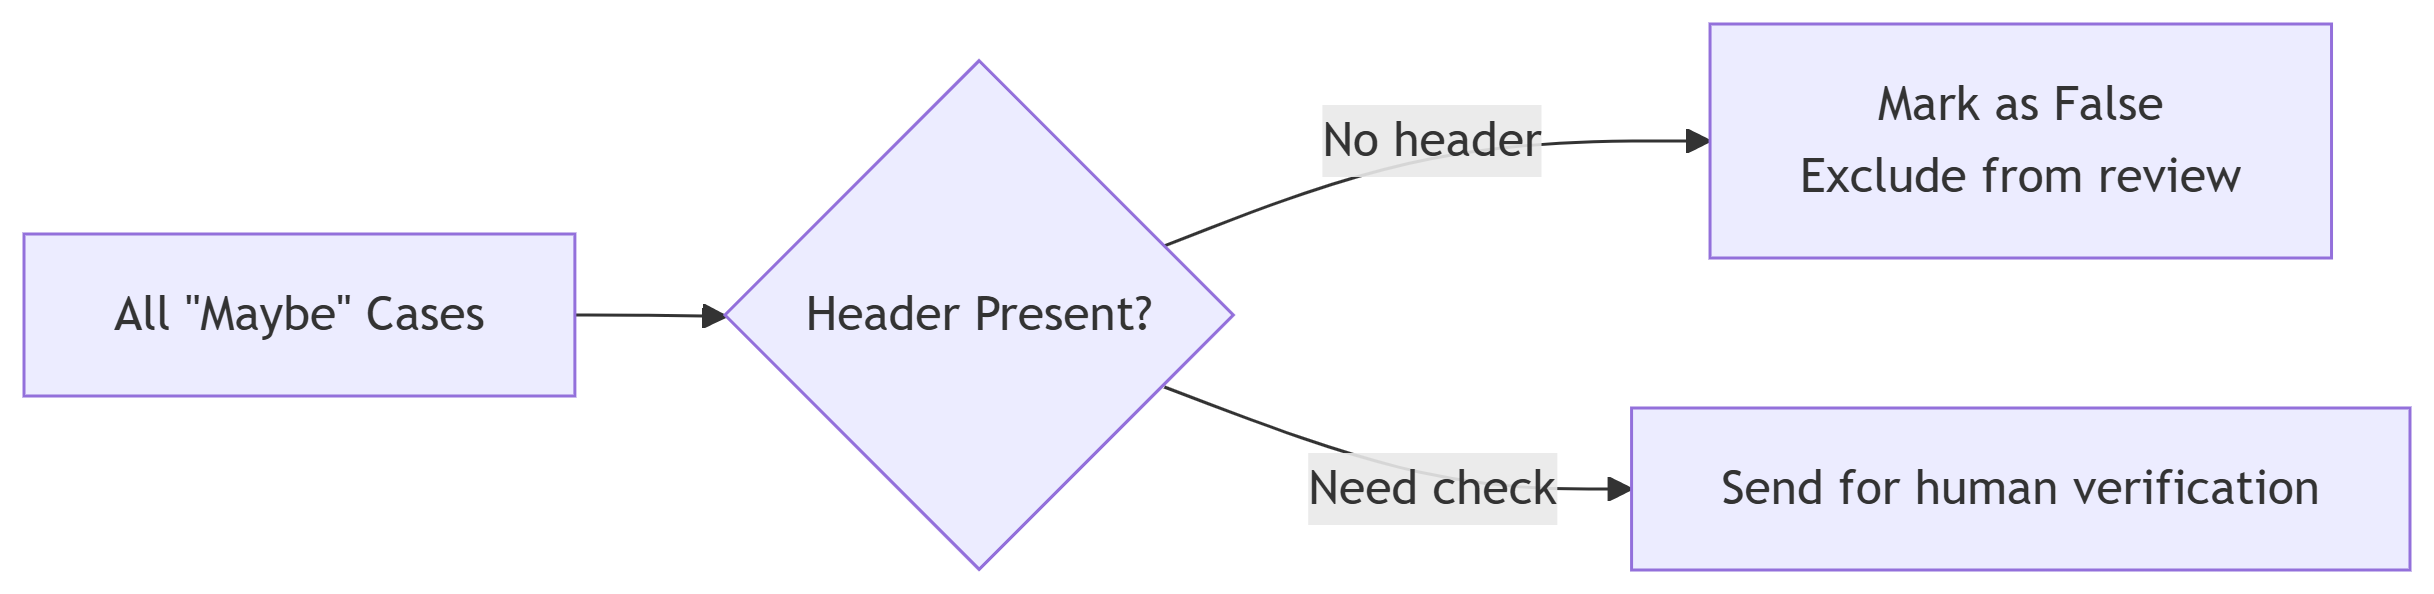

In [3]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\jj110\Downloads\deepseek_mermaid_20250624_a9e3bd.png"))


# 10 categories

In [ ]:
import pandas as pd
from openai import OpenAI
import time
import re

INPUT_CSV = r"C:\Users\output.csv"
OUTPUT_CSV = r"C:\Users\output_10 categories.csv"
DEEPSEEK_API_KEY = "YOUR_API_KEY_HERE" 
DEEPSEEK_BASE_URL = "https://api.deepseek.com"

# Initialize DeepSeek client
client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url=DEEPSEEK_BASE_URL)

df = pd.read_csv(INPUT_CSV, encoding='utf-8')

# For the old version
# Clean any previous results
df['das_type'] = None
df['urls'] = None



# New 10-category DAS classification prompt
CLASSIFICATION_PROMPT = """Classify this Data Availability Statement (DAS) into one of the following categories:

1. access_restricted – Ethical, legal, privacy, or third-party restrictions
2. combination – Mentions more than one sharing method (e.g., in paper + repository)
3. in_paper – Data are reported only in the paper
4. in_paper_and_SI – Data are reported in both paper and Supplemental Information
5. in_SI – Data are reported only in Supplemental Information
6. location_not_stated – Says data are available, but doesn't say where or how
7. NA_value – Says N/A or Not Applicable
8. other – Doesn't fit any of the categories
9. repository – Cites a public repository or website where data are stored
10. upon_request – Says to contact the author or group to access data

Respond ONLY with the category label (e.g., repository, in_paper_and_SI). If uncertain, choose the best fit.

DAS Content:
{content}
"""

# URL pattern for optional extraction
URL_PATTERN = r'(https?://\S+|www\.\S+|\S+\.(?:com|org|net|gov|edu|io)\b)'

def extract_urls(text):
    """Extract and clean all URLs from text"""
    urls = re.findall(URL_PATTERN, text, flags=re.IGNORECASE)
    cleaned_urls = [url.strip(').,;') for url in urls]
    return list(set(cleaned_urls))  # unique

def classify_das(content):
    """Classify DAS using DeepSeek API and normalize result"""
    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a research data availability classifier."},
                {"role": "user", "content": CLASSIFICATION_PROMPT.format(content=content)}
            ],
            temperature=0.0,
            max_tokens=10
        )

        raw = response.choices[0].message.content.strip().lower()
        
        # Extract label (handle cases like "7. NA_value")
        match = re.search(r'([a-z_]+)$', raw)
        if match:
            label = match.group(1)
        else:
            print(f"[Warning] Cannot parse label: '{raw}'")
            return None, []

        valid_labels = {
            "access_restricted", "combination", "in_paper", "in_paper_and_si", "in_si",
            "location_not_stated", "na_value", "other", "repository", "upon_request"
        }

        if label in valid_labels:
            return label, extract_urls(content)
        else:
            print(f"[Warning] Label not recognized: '{label}' from response '{raw}'")
            return None, []

    except Exception as e:
        print(f"[Error] Classification failed: {e}")
        return None, []

# Process only non-empty DAS content
non_empty_rows = df[df['das_content'].notna() & (df['das_content'].str.strip() != '')]
print(f"Processing {len(non_empty_rows)} rows with valid DAS content...")

for idx in non_empty_rows.index:
    row = df.loc[idx]
    print(f"Classifying row {idx + 1}: {row.get('filename', 'N/A')}")
    das_type, urls = classify_das(row['das_content'])
    df.at[idx, 'das_type'] = das_type
    df.at[idx, 'urls'] = '; '.join(urls) if urls else None
    time.sleep(1)  # Respect API rate limit

# Save output
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"✅ Done! Results saved to: {OUTPUT_CSV}")


Processing 55 rows with valid DAS content...
Classifying row 16: 10.1038_s42003-021-01732-y.pdf
Classifying row 18: 10.1136_bjophthalmol-2020-318199.pdf
Classifying row 19: 10.1136_bmjgh-2020-002427.pdf
Classifying row 20: 10.1136_injuryprev-2019-043296.pdf
Classifying row 21: 10.1136_rmdopen-2019-001008.pdf
Classifying row 23: 10.1186_s12872-020-01430-3.pdf
Classifying row 24: 10.1186_s12883-022-02752-9.pdf
Classifying row 25: 10.1186_s12885-017-3601-1.pdf
Classifying row 26: 10.1186_s12885-021-09067-x.pdf
Classifying row 28: 10.1186_s12889-018-6073-6.pdf
Classifying row 29: 10.1186_s12891-016-1090-z.pdf
Classifying row 30: 10.1186_s12891-020-03617-3.pdf
Classifying row 31: 10.1186_s12904-022-01069-1.pdf
Classifying row 32: 10.1186_s12935-022-02803-8.pdf
Classifying row 33: 10.1186_s12955-021-01692-1.pdf
Classifying row 35: 10.1186_s12966-020-01057-9.pdf
Classifying row 36: 10.1186_s12985-020-01454-3.pdf
Classifying row 37: 10.1186_s13020-020-00417-8.pdf
Classifying row 38: 10.1186_s1

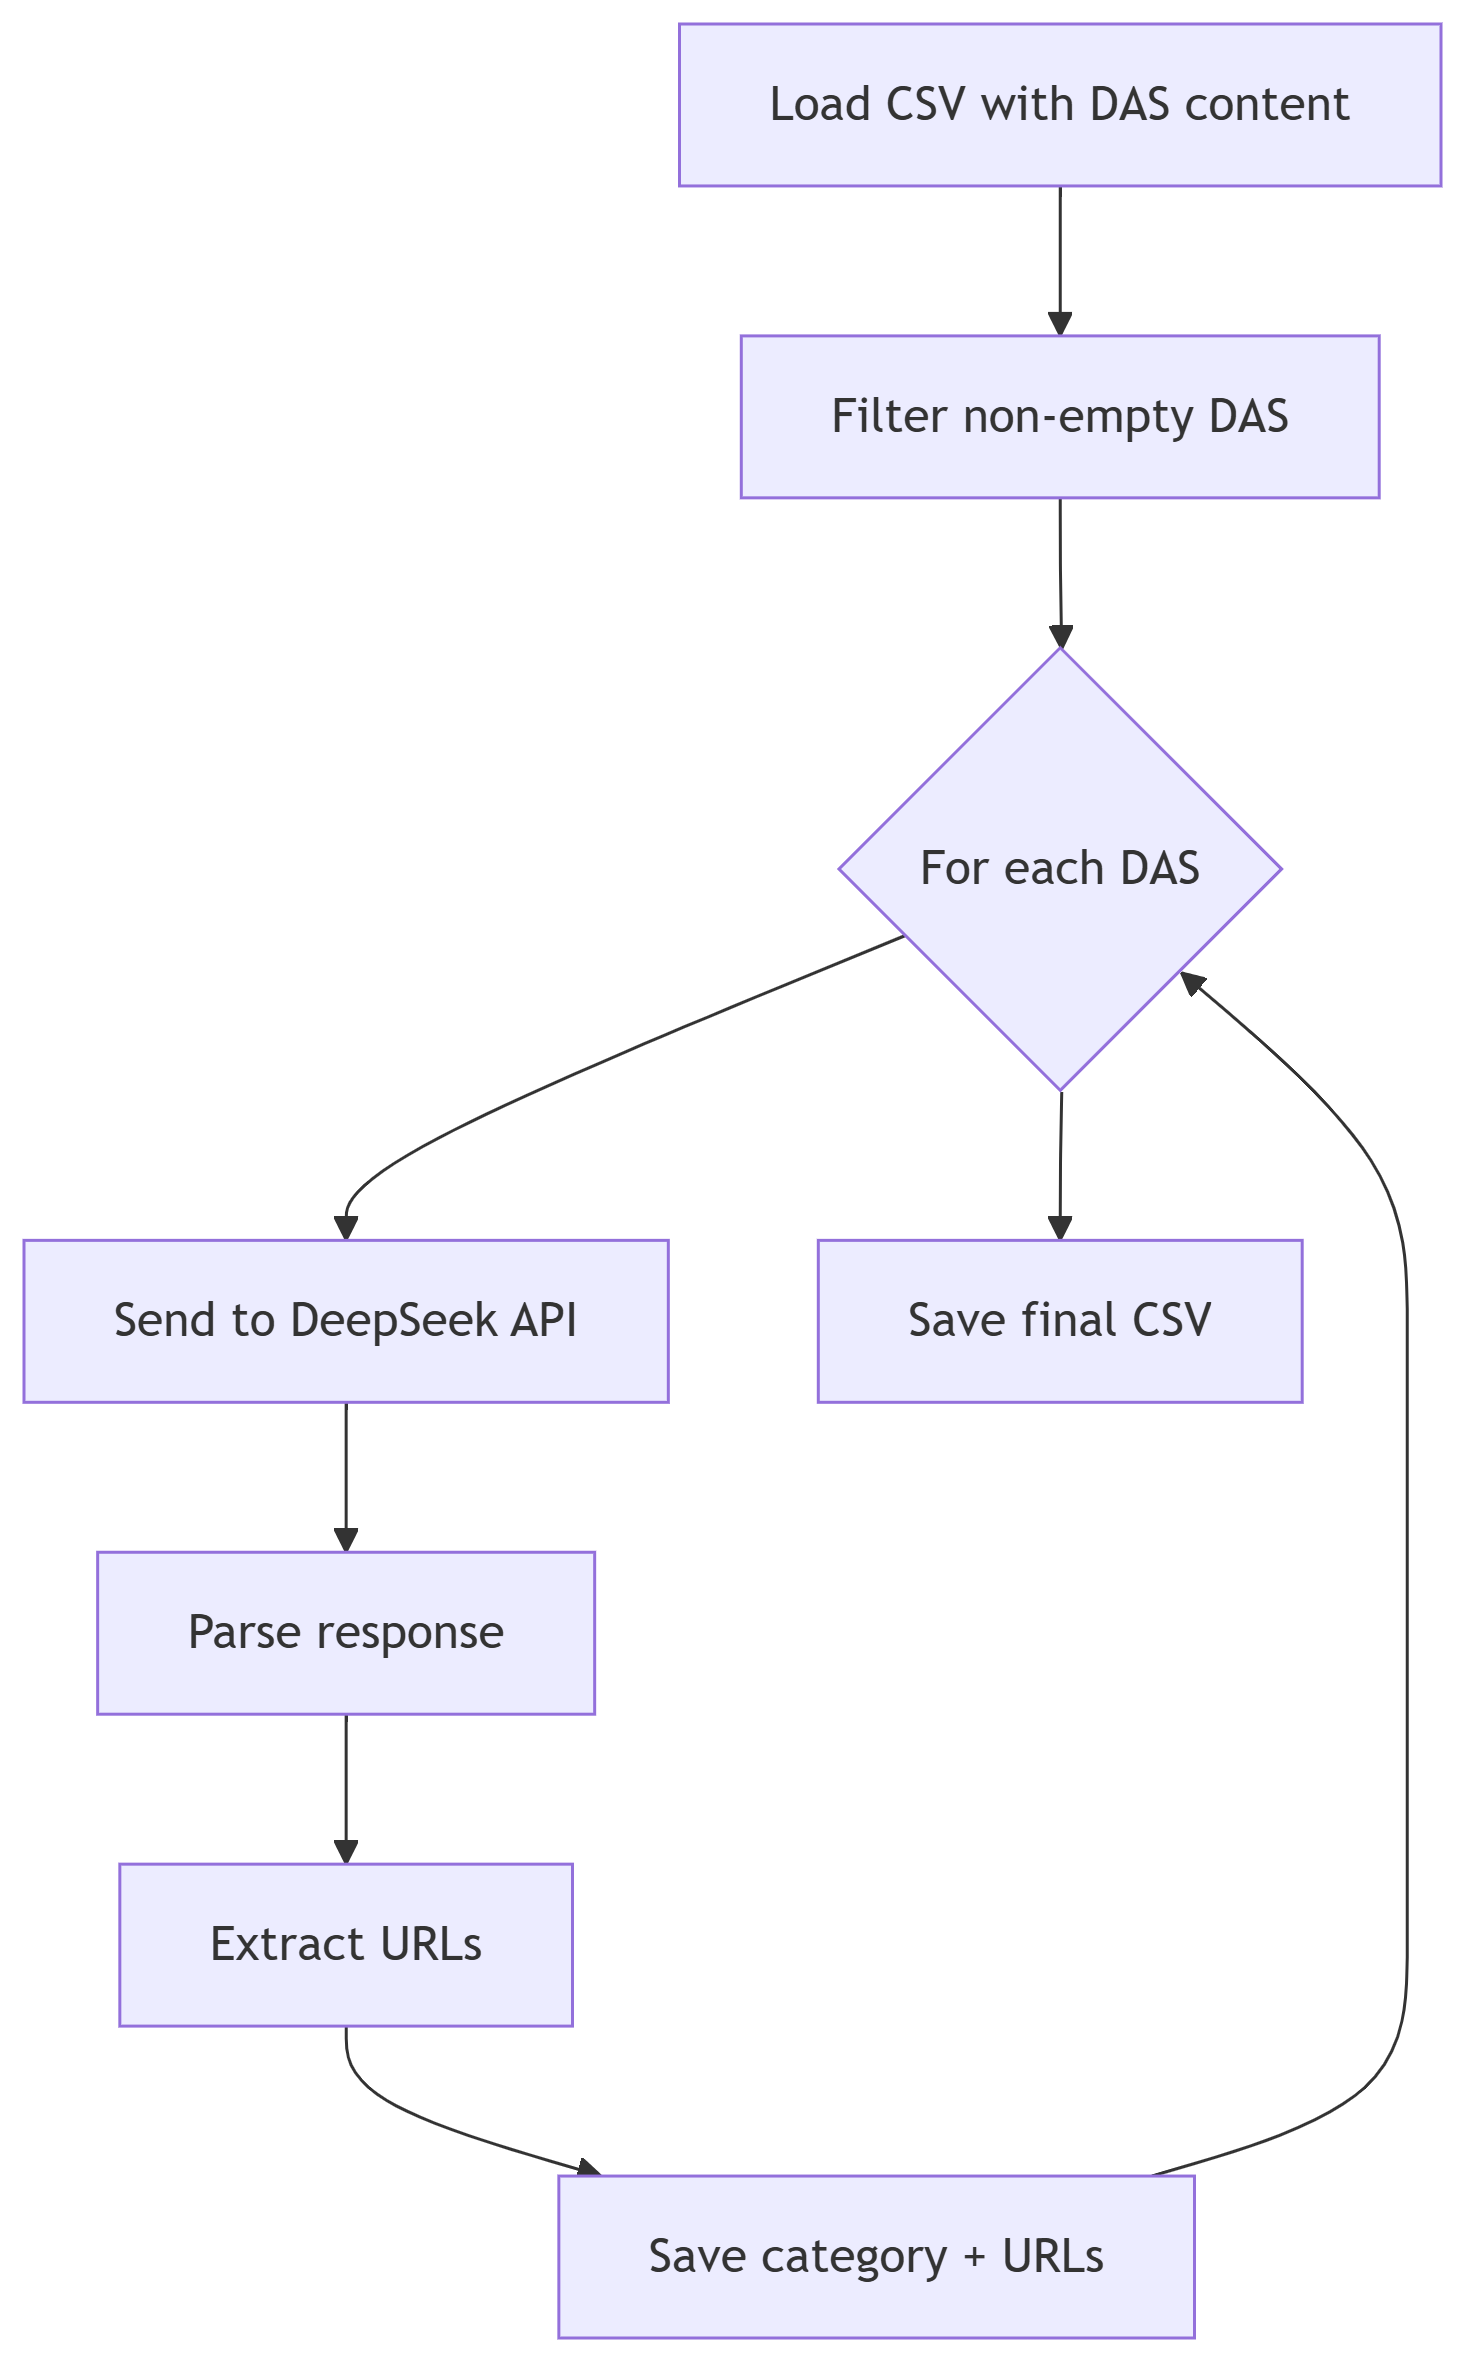

In [6]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\jj110\Downloads\deepseek_mermaid_20250624_7ad494.png", width=500))

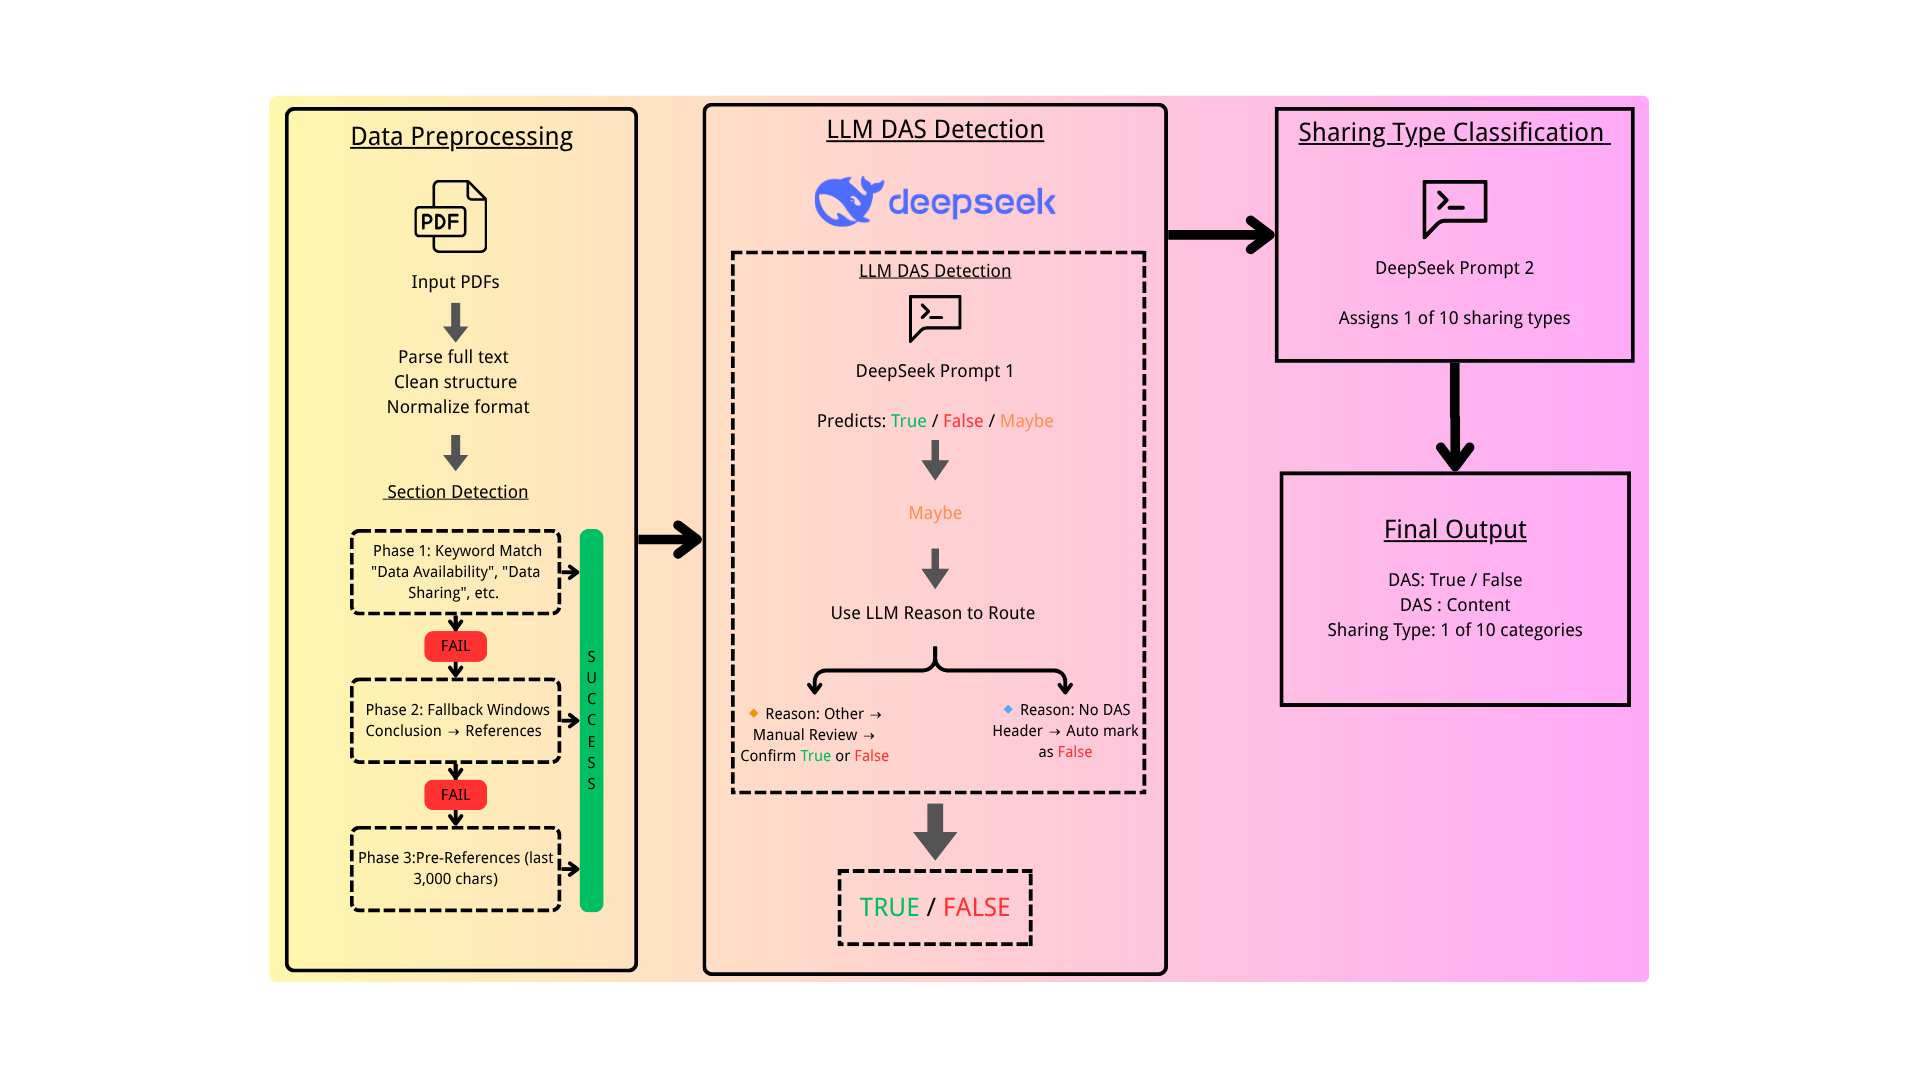

In [2]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\jj110\Downloads\1. Preprocessing 🠖 Input PDFs Parse full text Clean structure Normalize format (2).png"))
